In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [4]:
#collect and clean the data
sd = yf.download("^NSEI", interval='1d')
df=sd
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,4494.649902,0
2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,4546.200195,0
2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,4732.350098,0
2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,4747.549805,0
2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,4837.549805,0
...,...,...,...,...,...,...
2023-10-23,19521.599609,19556.849609,19257.849609,19281.750000,19281.750000,176000
2023-10-25,19286.449219,19347.300781,19074.150391,19122.150391,19122.150391,225300
2023-10-26,19027.250000,19041.699219,18837.849609,18857.250000,18857.250000,300400


<AxesSubplot:xlabel='Date'>

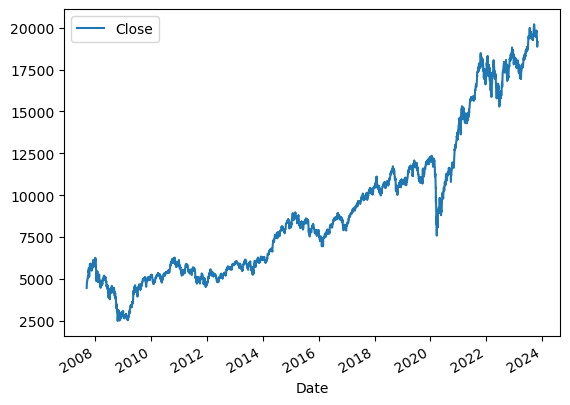

In [5]:
df.plot(y="Close")

In [6]:
#Train the model
X= df[["Open","High","Low","Volume"]]
X= X[:int(len(df)-1)]
y=df["Close"]
y= y[:int(len(df)-1)]


In [7]:
model = RandomForestRegressor()

In [8]:
model.fit(X,y)

RandomForestRegressor()

In [9]:
#Test the model
predictions = model.predict(X)
print("The model score is:", model.score(X,y))

The model score is: 0.9999815108048952


In [10]:
new_data = df[["Open","High","Low","Volume"]].tail(1)
prediction = model.predict(new_data)
print("Thye model predicts the last row or day to be :", prediction)


Thye model predicts the last row or day to be : [19088.03480469]


new_data = df[["Open","High","Low","Volume"]]
prediction = model.predict(new_data)

In [11]:
new_data = df[["Open","High","Low","Volume"]].tail(2)
prediction = model.predict(new_data)
prediction

array([18998.08841797, 19088.03480469])

In [12]:
ret_daily = df["Close"].pct_change(periods=1)
ret_daily

Date
2007-09-17         NaN
2007-09-18    0.011469
2007-09-19    0.040946
2007-09-20    0.003212
2007-09-21    0.018957
                ...   
2023-10-23   -0.013350
2023-10-25   -0.008277
2023-10-26   -0.013853
2023-10-27    0.010076
2023-10-30    0.004917
Name: Close, Length: 3951, dtype: float64

In [19]:
ret_daily.reset_index(0)

,Date,Close
0,2007-09-17,NaN
1,2007-09-18,0.011469
2,2007-09-19,0.040946
3,2007-09-20,0.003212
4,2007-09-21,0.018957
...,...,...
3946,2023-10-23,-0.013350
3947,2023-10-25,-0.008277
3948,2023-10-26,-0.013853
3949,2023-10-27,0.010076


In [13]:
sd = yf.download("^IXIC", interval='1d')
nsdq=sd
nsdq

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1971-02-05,100.000000,100.000000,100.000000,100.000000,100.000000,0
1971-02-08,100.839996,100.839996,100.839996,100.839996,100.839996,0
1971-02-09,100.760002,100.760002,100.760002,100.760002,100.760002,0
1971-02-10,100.690002,100.690002,100.690002,100.690002,100.690002,0
1971-02-11,101.449997,101.449997,101.449997,101.449997,101.449997,0
...,...,...,...,...,...,...
2023-10-24,13084.990234,13170.389648,13022.849609,13139.870117,13139.870117,4604720000
2023-10-25,13039.860352,13042.519531,12804.299805,12821.219727,12821.219727,4599850000
2023-10-26,12768.969727,12818.139648,12543.860352,12595.610352,12595.610352,4894900000


In [14]:
nsdq_ret = nsdq["Close"].pct_change(periods=1)
nsdq_ret

Date
1971-02-05         NaN
1971-02-08    0.008400
1971-02-09   -0.000793
1971-02-10   -0.000695
1971-02-11    0.007548
                ...   
2023-10-24    0.009336
2023-10-25   -0.024251
2023-10-26   -0.017597
2023-10-27    0.003763
2023-10-30    0.008080
Name: Close, Length: 13299, dtype: float64

In [15]:
#nsdq_ret.drop(columns="Date",inplace =False)
#nsdq_ret.drop(columns=nsdq_ret['date'], inplace=True)
nsdq_ret.drop(columns=nsdq_ret.columns[1:1], inplace=True)
nsdq_ret

AttributeError: 'Series' object has no attribute 'columns'

In [20]:
nsdq_ret.reset_index(0)

,Date,Close
0,1971-02-05,NaN
1,1971-02-08,0.008400
2,1971-02-09,-0.000793
3,1971-02-10,-0.000695
4,1971-02-11,0.007548
...,...,...
13294,2023-10-24,0.009336
13295,2023-10-25,-0.024251
13296,2023-10-26,-0.017597
13297,2023-10-27,0.003763


<AxesSubplot:xlabel='Date'>

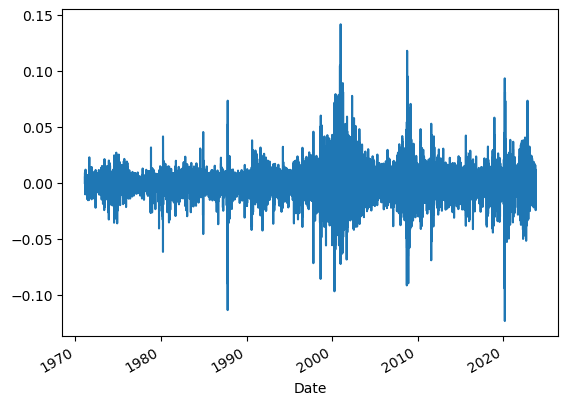

In [21]:
nsdq_ret.plot()

In [26]:
nsdq_ret.rename(columns = {'Close':'NSDQ_RET'}, inplace = True)

TypeError: rename() got an unexpected keyword argument 'columns'

In [ ]:
nsdq_vol = np.std(nsdq_ret)
nsdq_volroll=nsdq_ret.rolling(window=60).std()
nsdq_volroll
nsdq_volroll.plot()
#numpy.std(a, axis=None, dtype=None, out=None, ddof=0, keepdims=<no value>, *, where=<no value>)

In [23]:
df1 = pd.concat([nsdq_ret, ret_daily], axis=1, join='inner')
df1

,Close,Close
Date,,
2007-09-17,-0.007886,NaN
2007-09-18,0.027114,0.011469
2007-09-19,0.005589,0.040946
2007-09-20,-0.004572,0.003212
2007-09-21,0.006378,0.018957
...,...,...
2023-10-23,0.002659,-0.013350
2023-10-25,-0.024251,-0.008277
2023-10-26,-0.017597,-0.013853


In [25]:
df1.rename(columns = {'Close':'NSDQ_RET'}, inplace = True)
df1

,NSDQ_RET,NSDQ_RET
Date,,
2007-09-17,-0.007886,NaN
2007-09-18,0.027114,0.011469
2007-09-19,0.005589,0.040946
2007-09-20,-0.004572,0.003212
2007-09-21,0.006378,0.018957
...,...,...
2023-10-23,0.002659,-0.013350
2023-10-25,-0.024251,-0.008277
2023-10-26,-0.017597,-0.013853
